<a href="https://colab.research.google.com/github/Lufsenna/3-fase---2-Telecom-X-An-lise-de-Evas-o-de-Clientes-Churn---Parte-1/blob/main/C%C3%B3pia_de_Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Telecom X — Análise de Evasão de Clientes**

**# Telecom X - Análise de Evasão de Clientes**

A evasão de clientes **(Churn)** é um problema crítico para empresas de telecomunicações, pois impacta diretamente a receita e a sustentabilidade do negócio.

O objetivo deste projeto é analisar os dados de clientes da empresa Telecom X para identificar padrões e fatores que contribuem para o cancelamento dos serviços.

A partir dessa análise exploratória, busca-se gerar insights que possam auxiliar na criação de estratégias de retenção de clientes.

# **1. Importando bibliotecas**

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# **2. Extração dos dados (API)**

In [95]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


**Salvando o arquivo em CSV**

# **3. Estrutura do dataset - Conhecendo o Dataset**

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


# **4. Verificando Inconsistências nos Dados - Normalização do JSON**

In [97]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

df_final = pd.concat(
    [df['customerID'], df['Churn'], customer, phone, internet, account],
    axis=1
)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


**Salvando em CSV**

In [98]:
df.to_csv("telecomx_dados_tratados.csv", index=False)

**4.1 - Tratando as Inconsistências - Verificando tipos de dados**

In [99]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


**4.2 - Verificando valores nulos**

In [100]:
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


**Caso haja valores não nulos**

In [101]:
df_final = df_final.dropna()

**4.3 - Verificando duplicados**

In [102]:
df_final.duplicated().sum()

np.int64(0)

**Caso haja duplicidade**

In [103]:
df_final = df_final.drop_duplicates()

# **5. Corrigindo tipo da coluna TotalCharges**

In [104]:
df_final['Charges.Total'] = pd.to_numeric(
    df_final['Charges.Total'],
    errors='coerce'
)

# **6. Padronização e Transformação de Dados (Opcional)**

In [105]:
df_final = df_final.replace({
    'Yes':1,
    'No':0,
    'Female':0,
    'Male':1
})

/tmp/ipykernel_175/869496066.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final = df_final.replace({


# **7. Coluna de Contas Diárias (Opcional)**

In [106]:
df_final['Contas_Diarias'] = df_final['Charges.Monthly'] / 30

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


# **8. Análise descritiva**

In [107]:
df_final.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.505711,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2.157337
std,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,1.180833
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


# **8.1. Distribuição da Evasão**

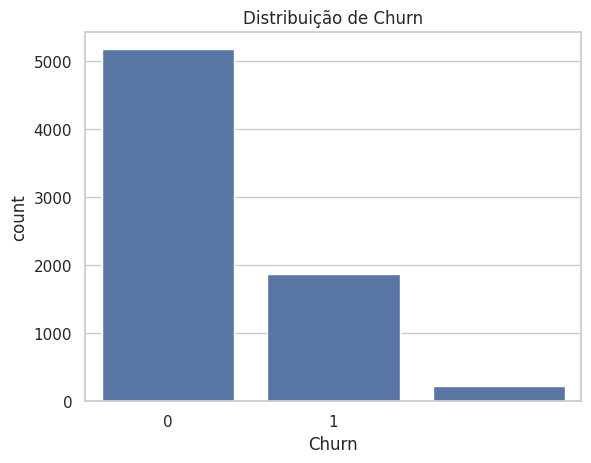

In [108]:
sns.countplot(data=df_final, x='Churn')

plt.title("Distribuição de Churn")
plt.show()

**8.2 - Percentual de churn**

In [109]:
df_final['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0,71.198569
1,25.719004
,3.082427


**8.3 - Churn por gênero**

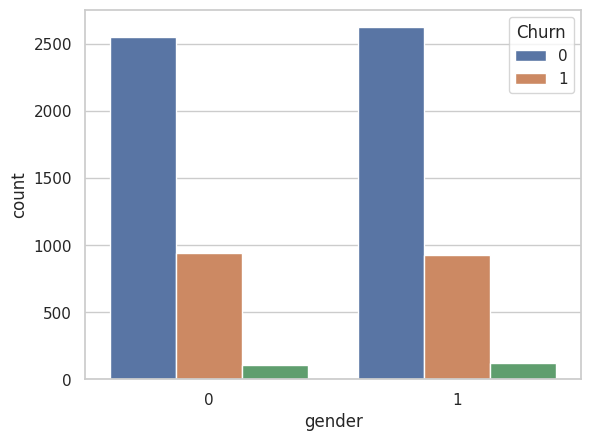

In [110]:
sns.countplot(data=df_final, x='gender', hue='Churn')
plt.show()

**8.4 - Churn por contrato**

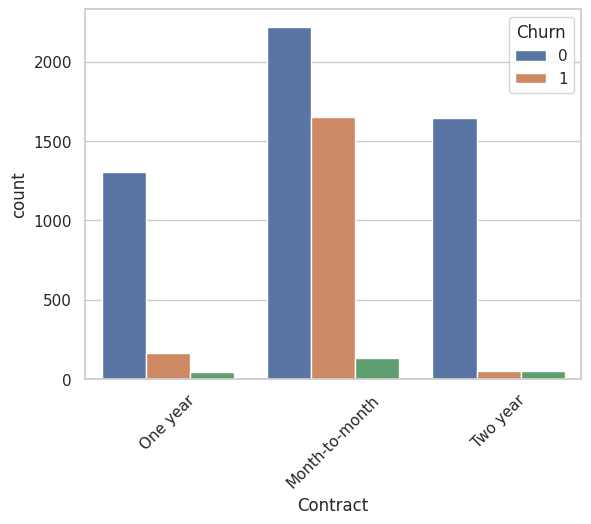

In [111]:
sns.countplot(data=df_final, x='Contract', hue='Churn')
plt.xticks(rotation=45)
plt.show()

**8.5 - Churn por método de pagamento**

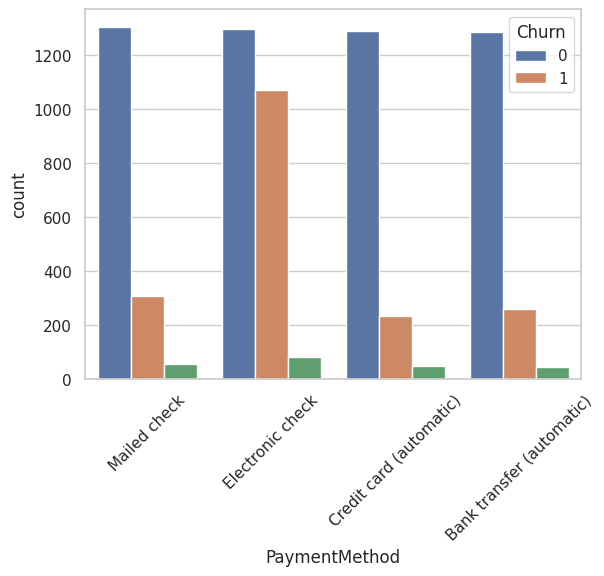

In [112]:
sns.countplot(data=df_final, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=45)
plt.show()

**8.6 - Variáveis numéricas**

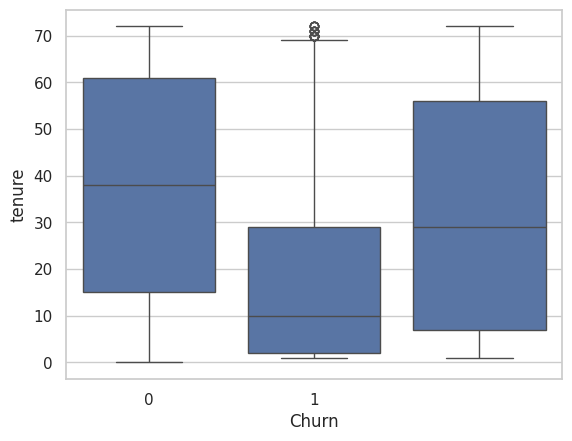

In [113]:
sns.boxplot(x='Churn', y='tenure', data=df_final)
plt.show()

**8.7 - Total gasto**

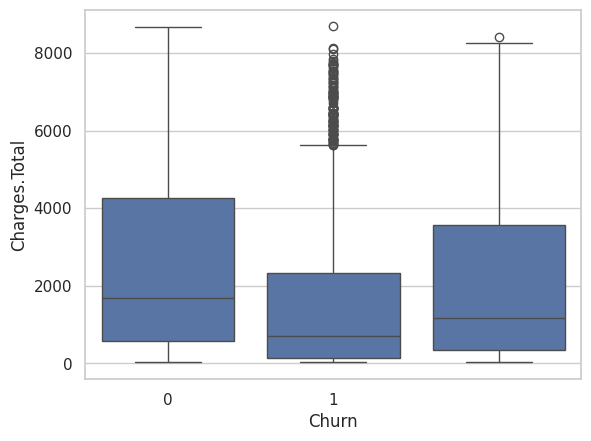

In [114]:
sns.boxplot(x='Churn', y='Charges.Total', data=df_final)
plt.show()

# **9. Cálculo detalhado da evasão**

**9.1 - Quantidade total de clientes**

In [115]:
total_clientes = df_final.shape[0]
total_clientes

7267

**9.2 - Quantidade de clientes que cancelaram**

In [116]:
clientes_churn = df_final[df_final['Churn'] == 1].shape[0]
clientes_churn

1869

**9.3 - Quantidade de clientes que permaneceram**

In [117]:
clientes_ativos = df_final[df_final['Churn'] == 0].shape[0]
clientes_ativos

5174

**9.4 - Percentual de evasão**

In [118]:
percentual_churn = (clientes_churn / total_clientes) * 100
percentual_churn

25.7190037154259

**9.5 - Percentual de permanência**

In [119]:
percentual_permanencia = (clientes_ativos / total_clientes) * 100
percentual_permanencia

71.19856887298748

**9.6 - Churn por tipo de contrato**

In [120]:
df_final['Churn'] = pd.to_numeric(df_final['Churn'], errors='coerce')
print(df_final.groupby('Contract')['Churn'].mean()*100)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


**9.7 - Tempo médio de clientes**

In [121]:
avg_tenure_by_churn = df_final.groupby('Churn')['tenure'].mean()

avg_tenure_no_churn = avg_tenure_by_churn[0.0]
avg_tenure_churned = avg_tenure_by_churn[1.0]

print(f"Tempo médio de permanência dos clientes (em meses):")
print(f"  Clientes que NÃO cancelaram (Churn = 0): {avg_tenure_no_churn:.2f} meses")
print(f"  Clientes que cancelaram (Churn = 1): {avg_tenure_churned:.2f} meses")
if avg_tenure_no_churn > 0:
    percentage_less_tenure_churn = ((avg_tenure_no_churn - avg_tenure_churned) / avg_tenure_no_churn) * 100
    print(f"\nEm média, clientes que cancelaram permaneceram {percentage_less_tenure_churn:.2f}% menos tempo do que aqueles que não cancelaram.")

Tempo médio de permanência dos clientes (em meses):
  Clientes que NÃO cancelaram (Churn = 0): 37.57 meses
  Clientes que cancelaram (Churn = 1): 17.98 meses

Em média, clientes que cancelaram permaneceram 52.14% menos tempo do que aqueles que não cancelaram.


**9.8 - Gasto médio mensal**

In [122]:
df_final.groupby('Churn')['Charges.Monthly'].mean()

,Charges.Monthly
Churn,
0.0,61.265124
1.0,74.441332


# **10. EXTRA — Correlação**

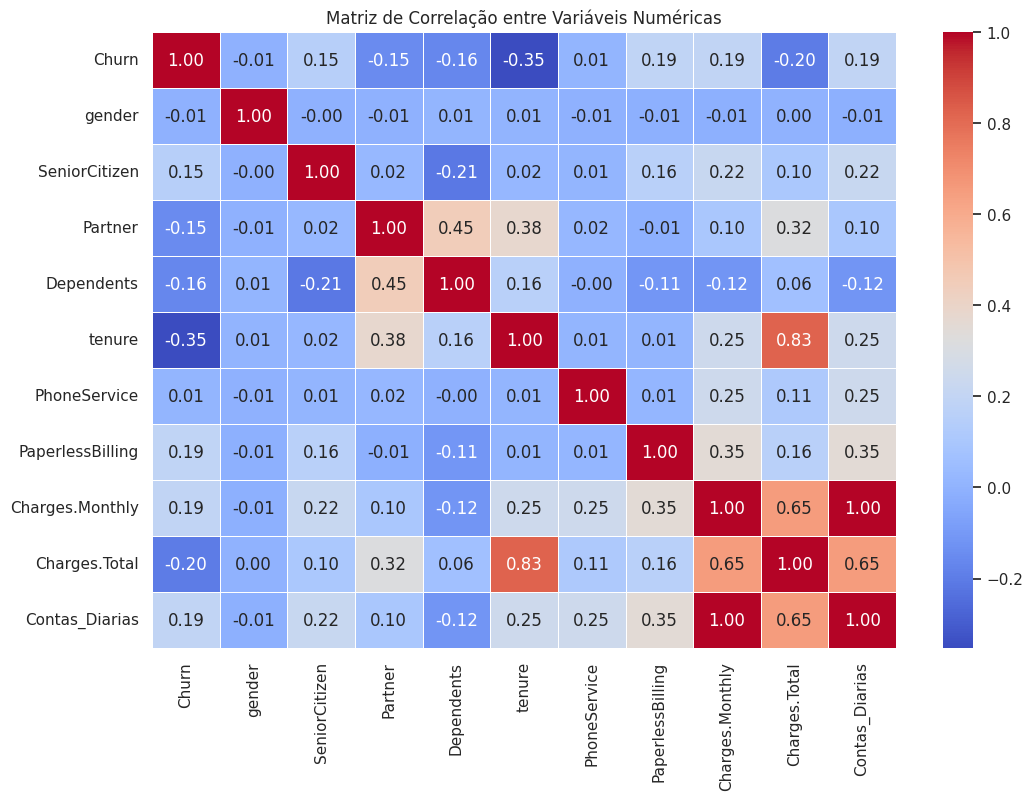

In [123]:
df_corr = df_final.select_dtypes(include=['int64','float64'])
corr = df_corr.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlação entre Variáveis Numéricas")

plt.show()

**10.1 - Correlação apenas com chu**rn

In [124]:
corr_churn = corr['Churn'].sort_values(ascending=False)

corr_churn

,Churn
Churn,1.000000
Charges.Monthly,0.193356
Contas_Diarias,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
PhoneService,0.011942
gender,-0.008612
Partner,-0.150448
Dependents,-0.164221
Charges.Total,-0.199484


**10.2 - Correlação das Variáveis com Churn**

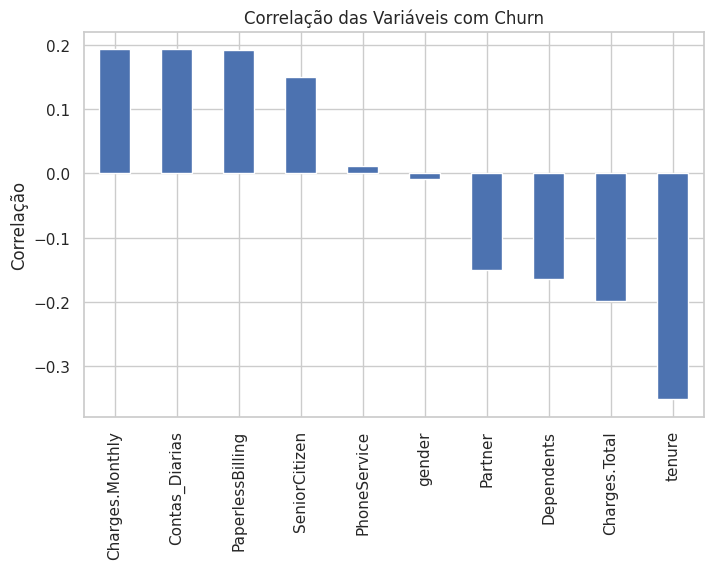

In [125]:
corr_churn.drop('Churn').plot(
    kind='bar',
    figsize=(8,5),
    title='Correlação das Variáveis com Churn'
)

plt.ylabel("Correlação")

plt.show()

# **11. Relatório**

**RELATÓRIO FINAL**

**Introdução**

A evasão de clientes (churn) é um dos principais desafios enfrentados por empresas de telecomunicações, pois impacta diretamente a receita e a sustentabilidade do negócio.

O objetivo desta análise é investigar os fatores associados ao cancelamento de clientes da empresa Telecom X, utilizando técnicas de análise exploratória de dados.


**Limpeza e tratamento de dados**

Os dados foram extraídos de uma API disponibilizada em formato JSON. Como o dataset possuía estrutura aninhada, foi necessário realizar a normalização das colunas utilizando a função json_normalize() da biblioteca Pandas.



**Durante o processo de tratamento foram realizadas as seguintes etapas:**

Verificação de valores ausentes;
Remoção de duplicatas;
Conversão de tipos de dados;
Padronização de variáveis categóricas.



**Criação da coluna Contas Diarias**

Essas etapas garantem maior qualidade e confiabilidade para as análises realizadas.



**Análise exploratória de dados**

O dataset possui aproximadamente 7043 clientes registrados.

**Desses:**

**5174 - clientes permaneceram na empresa**

**1869 - clientes cancelaram o serviço**

Isso representa uma taxa de **evasão** de aproximadamente **26,5%**, enquanto **73,5% **dos clientes permanecem **ativos**.


**A análise por tipo de contrato revelou diferenças significativas:**


**Contratos mensais** apresentam taxa de churn próxima de **42%**

**Contratos anuais **apresentam cerca de **11%**

**Contratos de dois anos** apresentam aproximadamente **3%**

Isso indica que clientes com contratos de longo prazo tendem a permanecer mais tempo na empresa.

Outra observação relevante refere-se ao tempo de permanência dos clientes. Clientes que cancelaram possuem em média 18 meses de contrato, enquanto clientes ativos possuem cerca de 37 meses de permanência.

Além disso, clientes que cancelaram apresentam, em média, gastos mensais ligeiramente maiores, o que pode indicar insatisfação com custo-benefício ou concorrência.

**Pontos positivos identificados**

A maioria dos clientes permanece na empresa

Contratos de longo prazo apresentam maior fidelização

Serviços adicionais podem contribuir para retenção



**Pontos negativos identificados**

Alta taxa de churn em contratos mensais

Maior evasão entre clientes com pouco tempo de permanência

Possível relação entre custo do serviço e cancelamento


**Recomendações**

**Com base nos resultados obtidos, algumas estratégias podem ajudar a reduzir a evasão:**


**Incentivar contratos de maior duração**

**Desenvolver programas de retenção para novos clientes**

**Oferecer benefícios ou descontos progressivos**

**Analisar estratégias de preço para clientes com maior gasto mensal**

**Essas ações podem contribuir para aumentar a fidelização e reduzir perdas de receita.**